# Overlap Sweep: Iris Binary (versicolor vs virginica)

**Goal:** Find the `overlap_std` threshold at which noisy evaluation starts degrading 
clean weights — so we know where noise mitigation techniques will actually help.

**What this notebook does:**
1. Loads Iris, drops setosa → binary classification: versicolor (−1) vs virginica (+1)
2. Adds 100 synthetic points per class at 4 overlap levels: `0.1, 0.2, 0.3, 0.4`
3. For each dataset: trains a **SVM** and a **VQC (clean simulator)**
4. Evaluates each trained model on 3 conditions:
   - `sim → sim` : clean weights, clean evaluation (upper bound)
   - `sim → noisy` : clean weights, noisy Aer evaluation (degradation signal)
   - `SVM` : classical baseline
5. Plots accuracy vs overlap across all conditions — the crossing point is where to focus

**Architecture:** same as `iris_vqc_antinoise_v2` — Data Reuploading VQC, `StronglyEntanglingLayers`, `N_LAYERS=5`


## 1. Imports & Configuration

In [ ]:
import os
import json
import pennylane as qml
from pennylane import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.svm import SVC
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

# Circuit
N_QUBITS   = 4
N_LAYERS   = 5
N_FEATURES = 4
SHOTS_HW   = 512

# Training
LEARNING_RATE = 0.05
N_EPOCHS      = 15
BATCH_SIZE    = 5

MODELS_DIR = "models_overlap"
os.makedirs(MODELS_DIR, exist_ok=True)

# Overlap levels to sweep
OVERLAP_LEVELS = [0.1, 0.2, 0.3, 0.4]
N_SYNTHETIC    = 100   # synthetic points added per class per overlap level

IBM_TOKEN = "token"

print(f"PennyLane {qml.__version__}")
print(f"N_LAYERS={N_LAYERS}  SHOTS_HW={SHOTS_HW}")
print(f"Overlap sweep: {OVERLAP_LEVELS}  |  {N_SYNTHETIC} synthetic pts/class")


PennyLane 0.44.1
N_LAYERS=5  SHOTS_HW=512
Overlap sweep: [0.1, 0.2, 0.3, 0.4]  |  100 synthetic pts/class


## 2. IBM Backend & Noise Model

In [3]:
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_aer.noise import NoiseModel

service = QiskitRuntimeService(
    channel="ibm_quantum_platform",
    token=IBM_TOKEN
)
ibm_backend = service.backend("ibm_marrakesh")
noise_model = NoiseModel.from_backend(ibm_backend)
print(f"Noise model loaded from: {ibm_backend.name}")


qiskit_runtime_service._discover_account:WARNING:2026-06-10 07:30:33,256: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-06-10 07:30:36,264: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: QML. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-10 07:30:36,266: Using instance: QML, plan: open


Noise model loaded from: ibm_marrakesh


## 3. Dataset Construction

**Binary task:** versicolor (class 1 → label −1) vs virginica (class 2 → label +1).  
Setosa is dropped — it is trivially separable and contributes nothing to the noise sensitivity study.

For each `overlap_std` in `[0.1, 0.2, 0.3, 0.4]`, we:
1. Start from the 100 real samples (50 versicolor + 50 virginica)
2. Compute the centroid of each class in the **scaled** feature space
3. Compute the midpoint between the two centroids
4. Sample `N_SYNTHETIC` points per class from a Gaussian centered at the midpoint  
   with std = `overlap_std` — these land directly in the decision boundary region
5. Split 70/30 train/test, stratified

The synthetic points are **identical across overlap levels except for the std**, so the
only variable is how much the classes bleed into each other.


In [4]:
def build_binary_iris_datasets(overlap_levels, n_synthetic=N_SYNTHETIC, seed=SEED):
    """
    Returns a dict: overlap_std -> {'X_train', 'y_train', 'X_test', 'y_test', 'n_total'}
    Labels: versicolor = -1, virginica = +1
    """
    iris = load_iris()
    # Keep only classes 1 (versicolor) and 2 (virginica)
    mask   = iris.target != 0
    X_raw  = iris.data[mask].astype(np.float64)
    y_raw  = iris.target[mask]                    # 1 or 2

    scaler   = MinMaxScaler(feature_range=(0, np.pi))
    X_scaled = scaler.fit_transform(X_raw)

    # Binary labels: versicolor → -1, virginica → +1
    y_binary = np.where(y_raw == 2, 1, -1).astype(np.float64)

    rng = np.random.default_rng(seed)
    datasets = {}

    for std in overlap_levels:
        # Midpoint between the two class centroids (in scaled space)
        c_neg    = X_scaled[y_binary == -1].mean(axis=0)
        c_pos    = X_scaled[y_binary ==  1].mean(axis=0)
        midpoint = (c_neg + c_pos) / 2

        # Synthetic points centered at midpoint ± small offset toward each centroid
        # Slight offset keeps label assignment geometrically honest
        offset = (c_pos - c_neg) * 0.1
        syn_neg = rng.normal(loc=midpoint - offset, scale=std, size=(n_synthetic, N_FEATURES))
        syn_pos = rng.normal(loc=midpoint + offset, scale=std, size=(n_synthetic, N_FEATURES))

        # Clip to valid range [0, π]
        syn_neg = np.clip(syn_neg, 0, np.pi)
        syn_pos = np.clip(syn_pos, 0, np.pi)

        X_aug = np.vstack([X_scaled, syn_neg, syn_pos])
        y_aug = np.concatenate([y_binary,
                                np.full(n_synthetic, -1.0),
                                np.full(n_synthetic,  1.0)])

        X_train, X_test, y_train, y_test = train_test_split(
            X_aug, y_aug, test_size=0.3, random_state=seed, stratify=y_aug
        )
        datasets[std] = {
            "X_train": X_train, "y_train": y_train,
            "X_test" : X_test,  "y_test" : y_test,
            "n_total": len(X_aug),
            "scaler" : scaler,
        }
        print(f"  overlap={std:.1f}  total={len(X_aug):3d}  "
              f"train={len(X_train)}  test={len(X_test)}  "
              f"pos_train={int((y_train==1).sum())}  neg_train={int((y_train==-1).sum())}")

    return datasets

print("Building datasets for each overlap level...")
datasets = build_binary_iris_datasets(OVERLAP_LEVELS)


Building datasets for each overlap level...
  overlap=0.1  total=300  train=210  test=90  pos_train=105  neg_train=105
  overlap=0.2  total=300  train=210  test=90  pos_train=105  neg_train=105
  overlap=0.3  total=300  train=210  test=90  pos_train=105  neg_train=105
  overlap=0.4  total=300  train=210  test=90  pos_train=105  neg_train=105


## 4. Visualise Datasets — Overlap Sweep

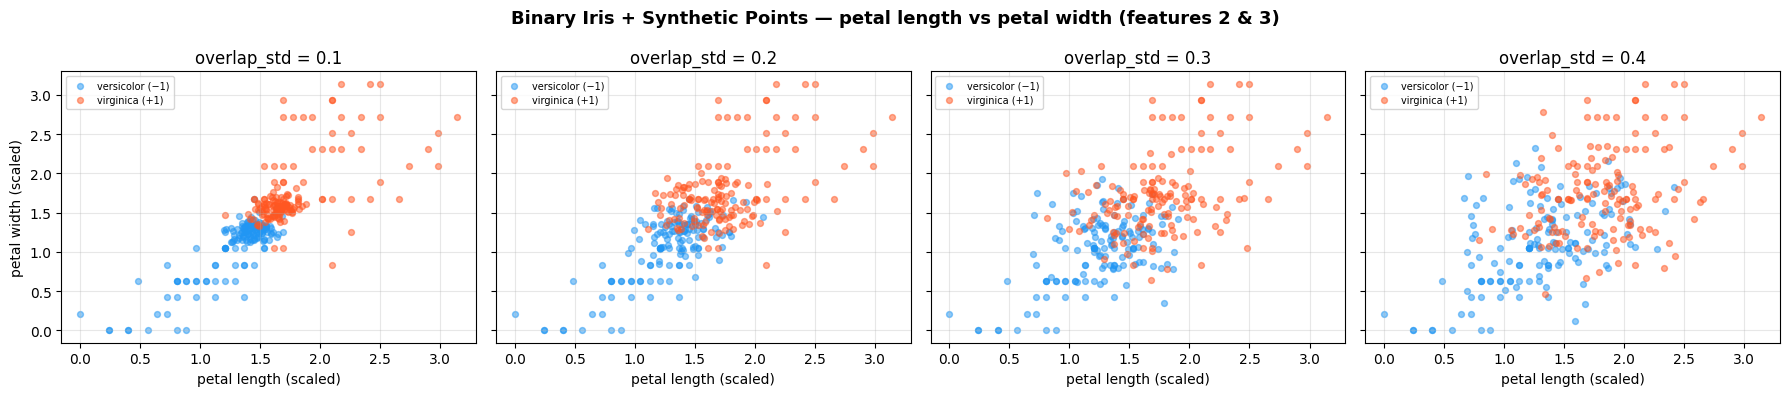

In [5]:
fig, axes = plt.subplots(1, len(OVERLAP_LEVELS), figsize=(18, 4), sharey=True)
fig.suptitle("Binary Iris + Synthetic Points — petal length vs petal width (features 2 & 3)",
             fontsize=13, fontweight='bold')

colors = {-1: "#2196F3", 1: "#FF5722"}
labels = {-1: "versicolor (−1)", 1: "virginica (+1)"}

for ax, std in zip(axes, OVERLAP_LEVELS):
    d = datasets[std]
    X_all = np.vstack([d["X_train"], d["X_test"]])
    y_all = np.concatenate([d["y_train"], d["y_test"]])

    # Original points (first 100 are the real Iris samples)
    for cls in [-1, 1]:
        idx = y_all == cls
        ax.scatter(X_all[idx, 2], X_all[idx, 3],
                   c=colors[cls], alpha=0.5, s=18, label=labels[cls])

    ax.set_title(f"overlap_std = {std}")
    ax.set_xlabel("petal length (scaled)")
    if ax == axes[0]:
        ax.set_ylabel("petal width (scaled)")
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 5. Circuit Architecture

Same VQC as `iris_vqc_antinoise_v2`:
- **Data reuploading**: `AngleEmbedding + StronglyEntanglingLayers` repeated `N_LAYERS` times
- **Measurement**: ⟨Z₀⟩ → sign → predicted label {+1, −1}
- **Clean circuit**: `default.qubit`, `diff_method=best` (Parameter-Shift)  
- **Noisy circuit**: `qiskit.aer` with `ibm_marrakesh` noise model, `SHOTS_HW=512`

Binary task means **one circuit per overlap level** (not 3 as in 1-vs-All).


Weight shape: (5, 4, 3)  (60 parameters)


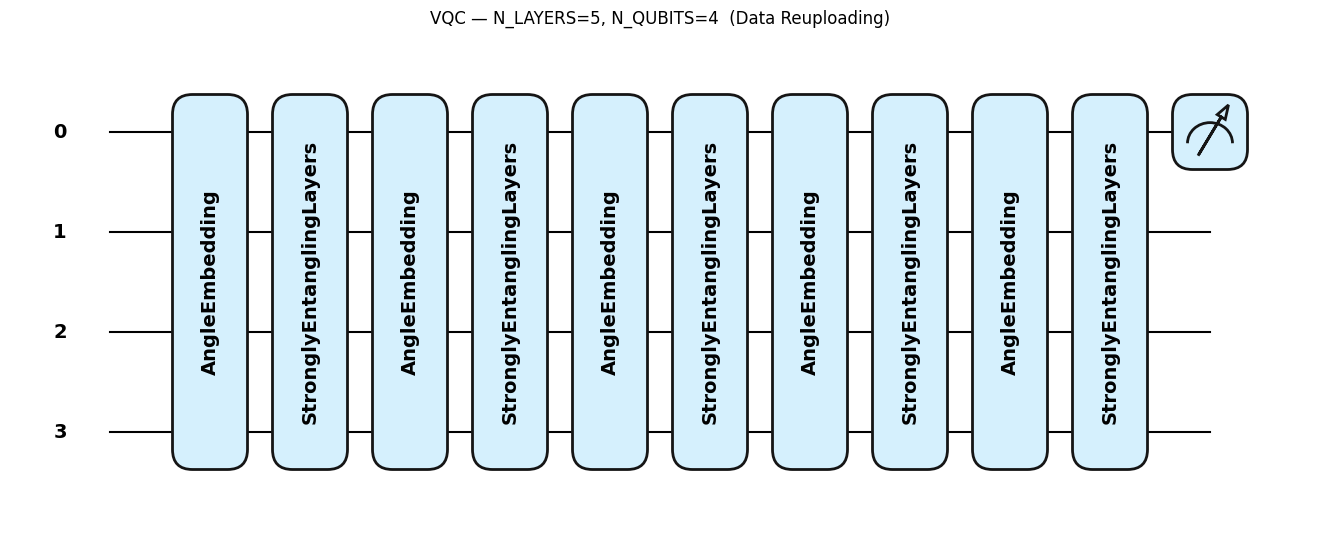

In [6]:
def create_vqc(device_name, n_qubits=N_QUBITS, n_layers=N_LAYERS, **device_kwargs):
    device      = qml.device(device_name, wires=n_qubits, **device_kwargs)
    weight_shape = qml.StronglyEntanglingLayers.shape(n_layers=n_layers, n_wires=n_qubits)

    @qml.qnode(device, diff_method="best")
    def circuit(inputs, weights):
        for layer_idx in range(n_layers):
            qml.AngleEmbedding(inputs, wires=range(n_qubits), rotation='Y')
            qml.StronglyEntanglingLayers(
                weights[layer_idx * (weight_shape[0] // n_layers):
                        (layer_idx + 1) * (weight_shape[0] // n_layers)],
                wires=range(n_qubits)
            )
        return qml.expval(qml.PauliZ(0))

    return circuit, weight_shape, device


def create_vqc_noisy(device_name, n_qubits=N_QUBITS, n_layers=N_LAYERS, **device_kwargs):
    device      = qml.device(device_name, wires=n_qubits, **device_kwargs)
    weight_shape = qml.StronglyEntanglingLayers.shape(n_layers=n_layers, n_wires=n_qubits)

    @qml.qnode(device)
    def circuit(inputs, weights):
        for layer_idx in range(n_layers):
            qml.AngleEmbedding(inputs, wires=range(n_qubits), rotation='Y')
            qml.StronglyEntanglingLayers(
                weights[layer_idx * (weight_shape[0] // n_layers):
                        (layer_idx + 1) * (weight_shape[0] // n_layers)],
                wires=range(n_qubits)
            )
        return qml.expval(qml.PauliZ(0))

    return circuit, weight_shape, device


# Instantiate circuits — one clean + one noisy (shared across overlap levels,
# only the dataset changes; the circuit topology is the same)
sim_circuit,   weight_shape, _      = create_vqc('default.qubit')
noisy_circuit, weight_shape, hw_dev = create_vqc_noisy(
    'qiskit.aer', shots=SHOTS_HW,
    backend='qasm_simulator', noise_model=noise_model
)

print(f"Weight shape: {weight_shape}  ({np.prod(weight_shape)} parameters)")

# Draw circuit
dummy_w = np.zeros(weight_shape)
dummy_x = np.zeros(N_FEATURES)
fig, ax = qml.draw_mpl(sim_circuit, decimals=None, style="pennylane")(dummy_x, dummy_w)
ax.set_title(f"VQC — N_LAYERS={N_LAYERS}, N_QUBITS={N_QUBITS}  (Data Reuploading)")
plt.tight_layout()
plt.show()


## 6. Training

For each overlap level we train:
- **VQC (clean)**: Adam optimiser, `default.qubit`, Parameter-Shift gradients
- **SVM**: RBF kernel, `C=1.0`, `gamma=scale` — same train split

Models are cached to `models_overlap/` so re-running the notebook doesn't retrain.  
Cache key: `sim_overlap{std}_weights.npy` — delete to force retrain.


In [7]:
def mse_loss(predictions, targets):
    return np.mean((predictions - targets) ** 2)


def train_vqc(circuit, weight_shape, X_train, y_train,
              n_epochs=N_EPOCHS, lr=LEARNING_RATE,
              batch_size=BATCH_SIZE, label=""):
    weights    = np.random.uniform(-np.pi, np.pi, weight_shape, requires_grad=True)
    opt        = qml.AdamOptimizer(stepsize=lr)
    loss_curve = []
    n_samples  = len(X_train)

    for epoch in range(n_epochs):
        perm   = np.random.permutation(n_samples)
        X_shuf = X_train[perm]
        y_shuf = y_train[perm]
        epoch_losses = []

        for start in range(0, n_samples, batch_size):
            X_b = X_shuf[start:start + batch_size]
            y_b = y_shuf[start:start + batch_size]

            def batch_cost(w):
                preds = np.array([circuit(x, w) for x in X_b])
                return mse_loss(preds, y_b)

            weights, loss_val = opt.step_and_cost(batch_cost, weights)
            epoch_losses.append(float(loss_val))

        mean_loss = float(np.mean(epoch_losses))
        loss_curve.append(mean_loss)
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"  [{label}] epoch {epoch+1:3d}/{n_epochs}  loss: {mean_loss:.4f}")

    return weights, loss_curve


def predict_binary(circuit, weights, X):
    scores = np.array([float(circuit(x, weights)) for x in X])
    return np.where(scores >= 0.0, 1, -1).astype(int)


def compute_metrics(y_true, y_pred):
    return {
        "accuracy" : accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, pos_label=1,  zero_division=0),
        "recall"   : recall_score(y_true, y_pred,    pos_label=1,  zero_division=0),
        "f1"       : f1_score(y_true, y_pred,         pos_label=1, zero_division=0),
    }


In [8]:
# ── Train VQC (clean) + SVM for every overlap level ─────────────────────────
vqc_weights  = {}   # overlap_std → trained weights
vqc_losses   = {}   # overlap_std → loss curve
svm_models   = {}   # overlap_std → fitted SVC

for std in OVERLAP_LEVELS:
    d      = datasets[std]
    tag    = f"{std:.1f}".replace(".", "")        # e.g. "01", "02"
    w_path = os.path.join(MODELS_DIR, f"sim_overlap{tag}_weights.npy")
    l_path = os.path.join(MODELS_DIR, f"sim_overlap{tag}_loss.json")

    print(f"\n{'─'*55}")
    print(f" overlap_std = {std}  ({d['n_total']} samples)")
    print(f"{'─'*55}")

    # VQC clean
    if os.path.exists(w_path):
        print("  VQC weights found — loading from disk.")
        weights    = np.load(w_path)
        with open(l_path) as f:
            loss_curve = json.load(f)
    else:
        weights, loss_curve = train_vqc(
            sim_circuit, weight_shape,
            d["X_train"], d["y_train"],
            label=f"sim/overlap={std}"
        )
        np.save(w_path, np.array(weights))
        with open(l_path, "w") as f:
            json.dump(loss_curve, f)
        print(f"  VQC saved → {w_path}")

    vqc_weights[std] = weights
    vqc_losses[std]  = loss_curve

    # SVM
    svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=SEED)
    svm.fit(d["X_train"], d["y_train"])
    svm_models[std] = svm
    svm_acc = accuracy_score(d["y_test"], svm.predict(d["X_test"]))
    print(f"  SVM test accuracy: {svm_acc:.3f}")

print("\nAll models ready.")



───────────────────────────────────────────────────────
 overlap_std = 0.1  (300 samples)
───────────────────────────────────────────────────────
  [sim/overlap=0.1] epoch   1/15  loss: 0.5908
  [sim/overlap=0.1] epoch   5/15  loss: 0.3947
  [sim/overlap=0.1] epoch  10/15  loss: 0.3490
  [sim/overlap=0.1] epoch  15/15  loss: 0.3625
  VQC saved → models_overlap/sim_overlap01_weights.npy
  SVM test accuracy: 0.956

───────────────────────────────────────────────────────
 overlap_std = 0.2  (300 samples)
───────────────────────────────────────────────────────
  [sim/overlap=0.2] epoch   1/15  loss: 0.6298
  [sim/overlap=0.2] epoch   5/15  loss: 0.5123
  [sim/overlap=0.2] epoch  10/15  loss: 0.5121
  [sim/overlap=0.2] epoch  15/15  loss: 0.4732
  VQC saved → models_overlap/sim_overlap02_weights.npy
  SVM test accuracy: 0.867

───────────────────────────────────────────────────────
 overlap_std = 0.3  (300 samples)
───────────────────────────────────────────────────────
  [sim/overlap=0.3]

## 7. Evaluation

Three conditions per overlap level:

| Condition | Weights | Evaluation circuit | Expected behaviour |
|---|---|---|---|
| `sim → sim` | VQC clean | `default.qubit` | Upper bound — unaffected by noise |
| `sim → noisy` | VQC clean | `qiskit.aer` + noise | Degrades as overlap increases AND circuit noise matters |
| `SVM` | RBF kernel | Classical | Classical ceiling for comparison |

The **key signal** is the gap between `sim → sim` and `sim → noisy`.  
If that gap grows with overlap, it means the noise is crossing the decision boundary —
and that is exactly where mitigation techniques will be useful.


In [9]:
rows = []

for std in OVERLAP_LEVELS:
    d = datasets[std]
    y_true = d["y_test"].astype(int)

    # Condition 1: sim weights → sim eval
    y_pred_ss = predict_binary(sim_circuit, vqc_weights[std], d["X_test"])
    m = compute_metrics(y_true, y_pred_ss)
    m.update({"overlap": std, "condition": "sim → sim"})
    rows.append(m)

    # Condition 2: sim weights → noisy eval
    y_pred_sn = predict_binary(noisy_circuit, vqc_weights[std], d["X_test"])
    m = compute_metrics(y_true, y_pred_sn)
    m.update({"overlap": std, "condition": "sim → noisy"})
    rows.append(m)

    # Condition 3: SVM
    y_pred_svm = svm_models[std].predict(d["X_test"]).astype(int)
    m = compute_metrics(y_true, y_pred_svm)
    m.update({"overlap": std, "condition": "SVM"})
    rows.append(m)

    print(f"overlap={std}  sim→sim={rows[-3]['accuracy']:.3f}  "
          f"sim→noisy={rows[-2]['accuracy']:.3f}  "
          f"SVM={rows[-1]['accuracy']:.3f}  "
          f"Δ(noisy-sim)={rows[-2]['accuracy']-rows[-3]['accuracy']:+.3f}")

results_df = pd.DataFrame(rows)[["overlap","condition","accuracy","precision","recall","f1"]]
pd.set_option('display.float_format', '{:.3f}'.format)
print("\n" + "="*70)
print(results_df.to_string(index=False))


overlap=0.1  sim→sim=0.933  sim→noisy=0.933  SVM=0.956  Δ(noisy-sim)=+0.000
overlap=0.2  sim→sim=0.844  sim→noisy=0.844  SVM=0.867  Δ(noisy-sim)=+0.000
overlap=0.3  sim→sim=0.811  sim→noisy=0.811  SVM=0.822  Δ(noisy-sim)=+0.000
overlap=0.4  sim→sim=0.756  sim→noisy=0.711  SVM=0.789  Δ(noisy-sim)=-0.044

 overlap   condition  accuracy  precision  recall    f1
   0.100   sim → sim     0.933      0.953   0.911 0.932
   0.100 sim → noisy     0.933      0.953   0.911 0.932
   0.100         SVM     0.956      0.956   0.956 0.956
   0.200   sim → sim     0.844      0.897   0.778 0.833
   0.200 sim → noisy     0.844      0.897   0.778 0.833
   0.200         SVM     0.867      0.884   0.844 0.864
   0.300   sim → sim     0.811      0.818   0.800 0.809
   0.300 sim → noisy     0.811      0.818   0.800 0.809
   0.300         SVM     0.822      0.837   0.800 0.818
   0.400   sim → sim     0.756      0.795   0.689 0.738
   0.400 sim → noisy     0.711      0.744   0.644 0.690
   0.400         SVM   

## 8. Visualisations

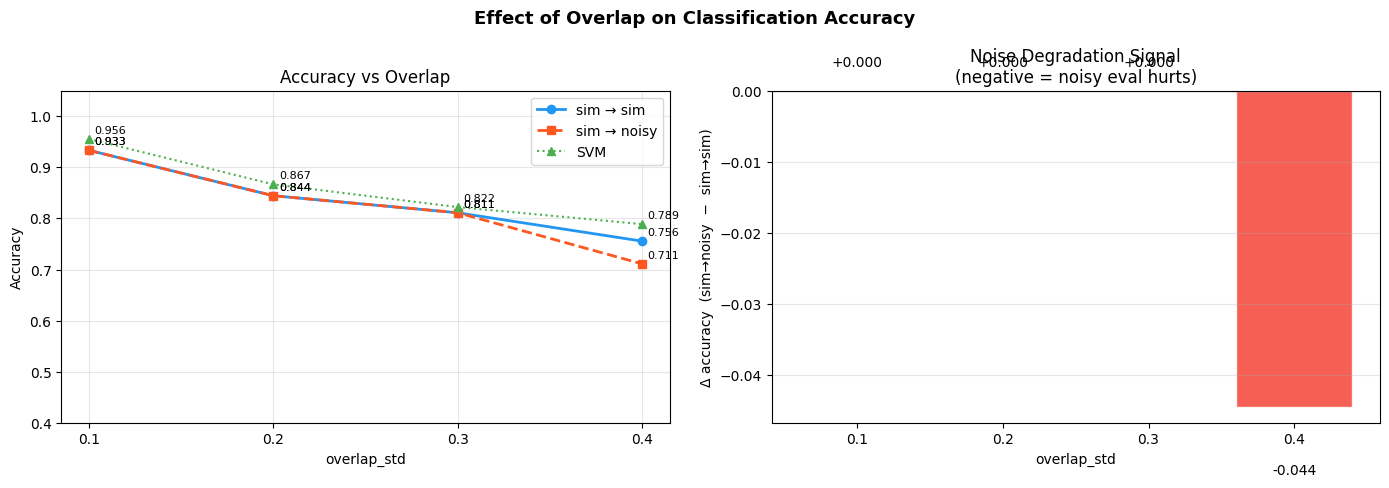

In [10]:
# ── 8.1 Accuracy vs overlap — main result ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Effect of Overlap on Classification Accuracy", fontsize=13, fontweight='bold')

condition_styles = {
    "sim → sim"  : {"color": "#2196F3", "marker": "o", "linestyle": "-",  "lw": 2.0},
    "sim → noisy": {"color": "#FF5722", "marker": "s", "linestyle": "--", "lw": 2.0},
    "SVM"        : {"color": "#4CAF50", "marker": "^", "linestyle": ":",  "lw": 1.5},
}

# Left: accuracy lines
ax = axes[0]
for cond, style in condition_styles.items():
    sub = results_df[results_df["condition"] == cond]
    ax.plot(sub["overlap"], sub["accuracy"],
            label=cond, **style)
    for _, row in sub.iterrows():
        ax.annotate(f"{row['accuracy']:.3f}",
                    (row["overlap"], row["accuracy"]),
                    textcoords="offset points", xytext=(4, 4), fontsize=8)

ax.set_xlabel("overlap_std")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy vs Overlap")
ax.set_xticks(OVERLAP_LEVELS)
ax.set_ylim(0.4, 1.05)
ax.legend()
ax.grid(alpha=0.3)

# Right: Δ accuracy (sim→noisy minus sim→sim) — noise degradation signal
ax = axes[1]
sim_sim   = results_df[results_df["condition"] == "sim → sim"  ].set_index("overlap")["accuracy"]
sim_noisy = results_df[results_df["condition"] == "sim → noisy"].set_index("overlap")["accuracy"]
delta     = sim_noisy - sim_sim

bar_colors = ["#4CAF50" if d >= 0 else "#F44336" for d in delta.values]
bars = ax.bar([str(s) for s in OVERLAP_LEVELS], delta.values,
              color=bar_colors, alpha=0.85, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
for bar, d in zip(bars, delta.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            d + (0.003 if d >= 0 else -0.008),
            f"{d:+.3f}", ha='center', va='bottom' if d >= 0 else 'top', fontsize=10)
ax.set_xlabel("overlap_std")
ax.set_ylabel("Δ accuracy  (sim→noisy  −  sim→sim)")
ax.set_title("Noise Degradation Signal\n(negative = noisy eval hurts)")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


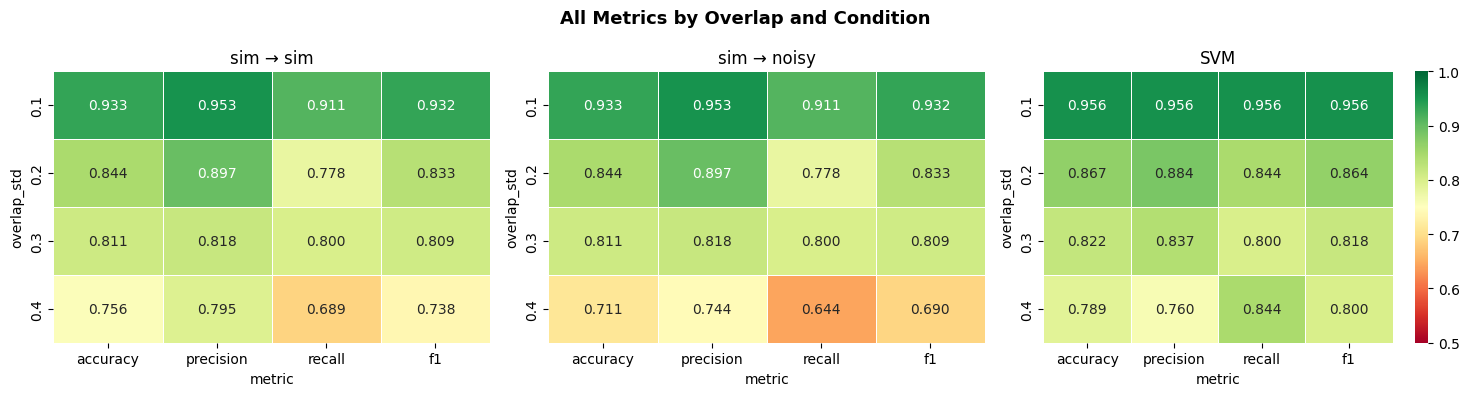

In [11]:
# ── 8.2 All metrics heatmap ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("All Metrics by Overlap and Condition", fontsize=13, fontweight='bold')

metrics = ["accuracy", "precision", "recall", "f1"]
for ax, cond in zip(axes, ["sim → sim", "sim → noisy", "SVM"]):
    sub   = results_df[results_df["condition"] == cond].set_index("overlap")[metrics]
    sns.heatmap(sub.astype(float), annot=True, fmt=".3f",
                cmap="RdYlGn", vmin=0.5, vmax=1.0,
                ax=ax, linewidths=0.5, cbar=(ax == axes[-1]))
    ax.set_title(cond)
    ax.set_xlabel("metric")
    ax.set_ylabel("overlap_std")

plt.tight_layout()
plt.show()


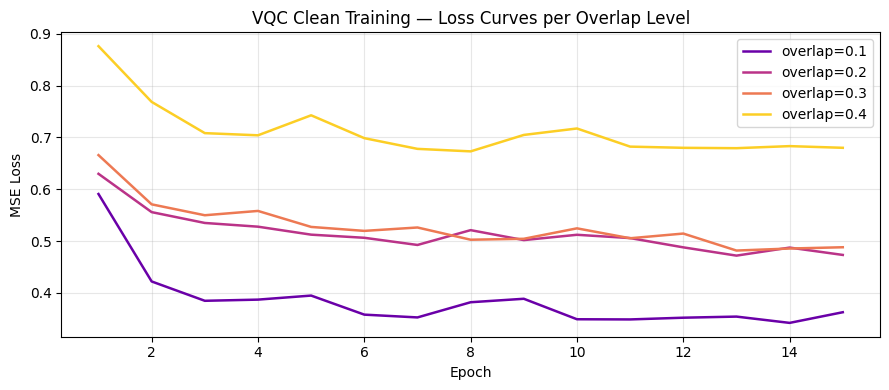

In [12]:
# ── 8.3 Loss curves — VQC clean training ────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
palette = plt.cm.plasma(np.linspace(0.2, 0.9, len(OVERLAP_LEVELS)))

for std, color in zip(OVERLAP_LEVELS, palette):
    ax.plot(range(1, N_EPOCHS + 1), vqc_losses[std],
            label=f"overlap={std}", color=color, linewidth=1.8)

ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_title("VQC Clean Training — Loss Curves per Overlap Level")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


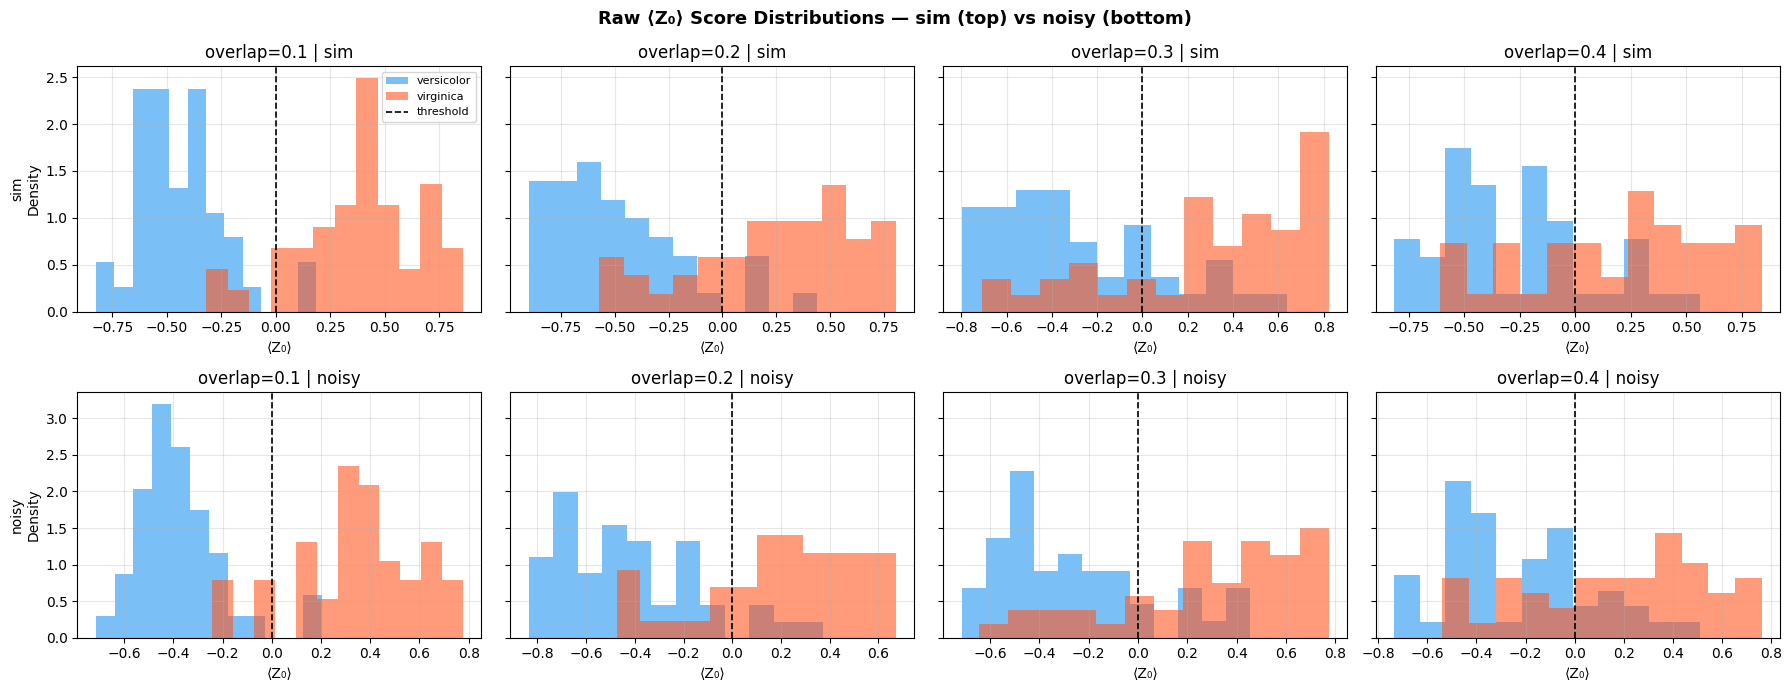

In [13]:
# ── 8.4 Raw ⟨Z₀⟩ scores — separability check ────────────────────────────────
# Shows whether the circuit is actually discriminating classes or outputting ~0 for everything.
# If the distributions overlap heavily at a given overlap_std, noise will easily flip predictions.
fig, axes = plt.subplots(2, len(OVERLAP_LEVELS), figsize=(18, 7), sharey='row')
fig.suptitle("Raw ⟨Z₀⟩ Score Distributions — sim (top) vs noisy (bottom)",
             fontsize=13, fontweight='bold')

for col, std in enumerate(OVERLAP_LEVELS):
    d      = datasets[std]
    w      = vqc_weights[std]
    y_test = d["y_test"]

    for row, (circuit, label) in enumerate([(sim_circuit,   "sim"),
                                             (noisy_circuit, "noisy")]):
        ax     = axes[row][col]
        scores = np.array([float(circuit(x, w)) for x in d["X_test"]])

        for cls, color, name in [(-1, "#2196F3", "versicolor"), (1, "#FF5722", "virginica")]:
            idx = y_test == cls
            ax.hist(scores[idx], bins=12, alpha=0.6, color=color,
                    label=name, density=True)

        ax.axvline(0, color='black', linestyle='--', linewidth=1.2, label='threshold')
        ax.set_title(f"overlap={std} | {label}")
        ax.set_xlabel("⟨Z₀⟩")
        if col == 0:
            ax.set_ylabel(f"{label}\nDensity")
        if row == 0 and col == 0:
            ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 9. Interpretation & Next Steps

Look at the **Δ accuracy plot (8.1 right)** and the **score distributions (8.4)**:

- **Δ ≈ 0 for all overlaps** → the noise of `ibm_marrakesh` is not strong enough to degrade 
  clean weights even with hard datasets. Circuit may be too shallow or ibm_marrakesh noise too low.
  → Try `N_LAYERS=7` or a higher noise backend.

- **Δ grows with overlap** → this is the ideal result. The crossing point (e.g. `overlap_std=0.2`) 
  is where to focus noise mitigation experiments. With high overlap, the decision boundary is 
  narrow and noise pushes samples across it.

- **Score distributions (8.4)** help diagnose separately:
  - If sim scores are well separated but noisy scores blur → classic noise degradation, ZNE/REM will help
  - If both are blurry → the circuit hasn't learned a good boundary → fix training first

**Recommended next step:**  
Pick the `overlap_std` where `|Δ|` is largest and proceed to the full noise mitigation notebook
with that dataset. That is the regime where REM, ZNE, and NAT will show meaningful differences.
